## Análisis exploratorio de datos (EDA

### By: Carlos Javier Palacios Sanchez

### Date: 8/18/2026

### Description:

Si su proyecto tiene muchos datos puede dividir el análisis en 3 notebooks diferentes:

Análisis univariable
Análisis bivariable
Análisis multivariable
En este proceso, se incluye :

Compresión detallada de las características y el esquema de datos.

Identificación de la preparación de datos y la ingeniería de atributos que se necesitan si se fuera a implementar un modelo de machine learning

Estudiar cada atributo y sus características (Análisis Univariable):

Nombre
Tipo de dato (categórico ordinal, nominal, numérico int / float, acotado / no acotado, texto, estructurado, fechas, etc.)
porcentaje (%) de valores nulos.
valores exactamente duplicados (filas y columnas)
Ruido y tipo de ruido (estocástico, valores atípicos, errores de redondeo, etc.)
¿Son posiblemente útiles para el proyecto?
Descripción estadística (dependiendo del tipo de dato): por ejemplo para los numéricos
Tendencia Central (media, mediana, moda, max, min, etc)
Medidas de dispersión (Rango, IQR, cuartiles, varianza, desviación estándar, skewness y kurtosis)
Tipo de distribución (gaussiana, uniforme, logarítmica, etc.)
Analice los datos para crear las reglas de validación de los datos que serán usadas en otra etapa del proyecto.
Para los proyectos de aprendizaje supervisado, identifique los atributos objetivo (target).

Visualización de los datos.

Estudiar las relaciones entre atributos (Análisis Bivariable)

Estudiar las relaciones entre varios atributos (Análisis Multivariable)

Estudiar cómo resolver el problema manualmente. (modelo simple Viable o heurísticas)

Identificar las transformaciones que tal vez se puedan aplicar.

Identificar datos adicionales que pueden ser útiles.

Puede utilizar las librerías o herramientas que considere para resolver la tarea y contestar las preguntas.
Utilice sistemas automáticos como Data science Agent pueden ver un tutorial en este Link

Entregables
Notebook con los resultados del análisis exploratorio de los datos, conclusiones e información de los datos
¿Sugerir si se puede realizar un modelo Heurístico que sea viable?

Se debe realizar un Pull request para ingresar el notebook a la ramamain para esto debe tener mínimo 1 revisiones de otras personas del Curso y que pase los check del CI/CD.


# Notebook 1 — Análisis Univariable
## Dataset `corazon.csv` — Enfermedad cardíaca

**Objetivo del notebook:** comprender en detalle el esquema y cada atributo de forma
aislada, auditar la calidad de los datos y derivar las **reglas de validación** que
usarán las etapas posteriores del proyecto.

| | |
|---|---|
| **Fuente** | `corazon.csv` |
| **Tipo de problema** | Clasificación binaria supervisada |
| **Variable objetivo (target)** | `disease` (0 = sin enfermedad, 1 = con enfermedad) |
| **Notebooks del proyecto** | 1 · Univariable — 2 · Bivariable — 3 · Multivariable + heurística |

### Contenido
1. Carga y esquema crudo
2. Diccionario de datos
3. Auditoría de calidad: nulos, duplicados y ruido
4. Reglas de validación y limpieza
5. Análisis univariable de variables numéricas
6. Análisis univariable de variables categóricas
7. Detección de valores atípicos
8. Identificación del target y balance de clases
9. Transformaciones sugeridas y datos adicionales útiles
10. Conclusiones y exportación del dataset validado


In [14]:
# =====================================================================
# Configuracion del entorno y estilo grafico
# =====================================================================
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Paleta categorica validada (orden fijo, nunca ciclado)
PAL = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
TXT, TXT2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"

# Rampa secuencial (un solo tono, claro -> oscuro)
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#eaf2fc", "#2a78d6", "#123a69"])
# Rampa divergente (dos tonos + gris neutro en el centro)
DIV = LinearSegmentedColormap.from_list("div_bo", ["#2a78d6", "#f2f2f0", "#eb6834"])

mpl.rcParams.update(
    {
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "axes.edgecolor": GRID,
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.alpha": 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlecolor": TXT,
        "axes.labelsize": 10,
        "axes.labelcolor": TXT2,
        "xtick.color": TXT2,
        "ytick.color": TXT2,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "font.size": 10,
        "figure.dpi": 110,
        "lines.linewidth": 2.0,
        "lines.markersize": 8,
        "axes.prop_cycle": mpl.cycler(color=PAL),
    }
)


def titulo(ax, t, sub=None):
    ax.set_title(t, loc="left", pad=12 if sub else 8)
    if sub:
        ax.text(
            0, 1.02, sub, transform=ax.transAxes, fontsize=9, color=TXT2, va="bottom"
        )


print("Entorno listo | pandas", pd.__version__, "| numpy", np.__version__)


Entorno listo | pandas 3.0.5 | numpy 2.5.2


---
## 1. Carga y esquema crudo

Se carga el archivo **sin ningún tipo de casting automático** (`dtype=str`) para poder
observar los datos exactamente como llegan, incluido el ruido. Si dejáramos que pandas
infiriera los tipos perderíamos evidencia sobre los valores corruptos.

In [15]:
from pathlib import Path

# Buscar el archivo aunque esté dentro de una carpeta del proyecto
base = Path.cwd()
candidatos = [
    ruta
    for raiz in [base, *base.parents]
    for ruta in raiz.rglob("*.csv")
    if ruta.name.lower() == "corazon.csv"
]

if not candidatos:
    raise FileNotFoundError(
        f"No se encontró corazon.csv desde {base}. "
        "Verifique que el archivo esté incluido en el repositorio."
    )

DATA_PATH = candidatos[0]
crudo = pd.read_csv(DATA_PATH, dtype=str, keep_default_na=True)

print(f"Archivo cargado: {DATA_PATH}")

print(f"Filas: {crudo.shape[0]:,}   Columnas: {crudo.shape[1]}")
print(f"Memoria: {crudo.memory_usage(deep=True).sum() / 1024:,.1f} KB")
crudo.head(10)

Archivo cargado: /workspaces/Heart---Data-Science-Project/notebooks/1-data/corazon.csv
Filas: 3,030   Columnas: 14
Memoria: 2,176.1 KB


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,1,left ventricular hypertrophy,150,0,2.3,3,0.0,fixed,0
1,67,Male,asymptomatic,160,286,0,left ventricular hypertrophy,108,1,1.5,2,3.0,normal,1
2,67,Male,asymptomatic,120,229,0,left ventricular hypertrophy,129,1,2.6,2,2.0,reversable,1
3,37,Male,nonanginal,130,250,0,normal,187,0,3.5,3,0.0,normal,0
4,41,Female,nontypical,130,204,0,left ventricular hypertrophy,172,0,1.4,1,0.0,normal,0
5,56,Male,nontypical,120,236,0,normal,178,0,0.8,1,0.0,normal,0
6,62,Female,asymptomatic,140,268,0,left ventricular hypertrophy,160,0,3.6,3,2.0,normal,1
7,57,Female,asymptomatic,120,354,0,normal,163,1,0.6,1,0.0,normal,0
8,63,Male,asymptomatic,130,254,0,left ventricular hypertrophy,147,0,1.4,2,1.0,reversable,1
9,53,Male,asymptomatic,140,203,1,left ventricular hypertrophy,155,1,3.1,3,0.0,reversable,1


In [16]:
# Esquema tal como lo infiere pandas por defecto (para contraste)
inferido = pd.read_csv(DATA_PATH)
esquema = pd.DataFrame(
    {
        "dtype_inferido": inferido.dtypes.astype(str),
        "no_nulos": inferido.notna().sum(),
        "nulos": inferido.isna().sum(),
        "valores_unicos": inferido.nunique(),
        "ejemplo": [inferido[c].dropna().iloc[0] for c in inferido.columns],
    }
)
esquema

,dtype_inferido,no_nulos,nulos,valores_unicos,ejemplo
age,str,3000,30,43,63
sex,str,2969,61,5,Male
chest_pain,str,2947,83,7,typical
rest_bp,str,2949,81,52,145
chol,str,2945,85,154,233
fbs,float64,2933,97,2,1.000
rest_ecg,str,2837,193,8,left ventricular hypertrophy
max_hr,str,2859,171,92,150
exang,str,2879,151,4,0
old_peak,str,2880,150,42,2.3


> **Observación crítica.** Columnas que *deberían* ser numéricas (`age`, `rest_bp`,
> `chol`, `max_hr`, `old_peak`, `exang`, `slope`, `ca`, `disease`) llegan como `object`.
> Eso solo puede ocurrir si contienen texto mezclado con números: **hay ruido inyectado
> en el archivo**. Lo confirmamos en la sección 3.

---
## 2. Diccionario de datos

Documentación de cada atributo: significado clínico, tipo de dato conceptual y dominio
esperado. Este diccionario es la base de las reglas de validación de la sección 4.

In [17]:
diccionario = pd.DataFrame(
    [
        ("age", "Edad del paciente en años", "Numérico entero, acotado", "[18, 100]"),
        ("sex", "Sexo biológico", "Categórico nominal", "{Male, Female}"),
        (
            "chest_pain",
            "Tipo de dolor torácico",
            "Categórico nominal",
            "{typical, nontypical, nonanginal, asymptomatic}",
        ),
        (
            "rest_bp",
            "Presión arterial en reposo (mm Hg) al ingreso",
            "Numérico entero, acotado",
            "[80, 220]",
        ),
        ("chol", "Colesterol sérico (mg/dl)", "Numérico entero, acotado", "[100, 700]"),
        ("fbs", "Glucemia en ayunas > 120 mg/dl", "Categórico binario", "{0, 1}"),
        (
            "rest_ecg",
            "Resultado del electrocardiograma en reposo",
            "Categórico nominal",
            "{normal, left ventricular hypertrophy, ST-T wave abnormality}",
        ),
        (
            "max_hr",
            "Frecuencia cardíaca máxima alcanzada en la prueba de esfuerzo",
            "Numérico entero, acotado",
            "[60, 220]",
        ),
        ("exang", "Angina inducida por el ejercicio", "Categórico binario", "{0, 1}"),
        (
            "old_peak",
            "Depresión del segmento ST inducida por ejercicio vs reposo",
            "Numérico flotante, acotado",
            "[0, 7]",
        ),
        (
            "slope",
            "Pendiente del segmento ST en el pico del ejercicio",
            "Categórico ORDINAL",
            "{1=ascendente, 2=plana, 3=descendente}",
        ),
        (
            "ca",
            "Nº de vasos principales coloreados por fluoroscopia",
            "Numérico discreto / ordinal",
            "{0, 1, 2, 3}",
        ),
        (
            "thal",
            "Resultado de la gammagrafía con talio",
            "Categórico nominal",
            "{normal, fixed, reversable}",
        ),
        (
            "disease",
            "TARGET — presencia de enfermedad cardíaca",
            "Categórico binario (target)",
            "{0=no, 1=sí}",
        ),
    ],
    columns=["atributo", "descripción", "tipo de dato", "dominio esperado"],
)

diccionario.style.set_properties(**{"text-align": "left"}).hide(axis="index")

atributo,descripción,tipo de dato,dominio esperado
age,Edad del paciente en años,"Numérico entero, acotado","[18, 100]"
sex,Sexo biológico,Categórico nominal,"{Male, Female}"
chest_pain,Tipo de dolor torácico,Categórico nominal,"{typical, nontypical, nonanginal, asymptomatic}"
rest_bp,Presión arterial en reposo (mm Hg) al ingreso,"Numérico entero, acotado","[80, 220]"
chol,Colesterol sérico (mg/dl),"Numérico entero, acotado","[100, 700]"
fbs,Glucemia en ayunas > 120 mg/dl,Categórico binario,"{0, 1}"
rest_ecg,Resultado del electrocardiograma en reposo,Categórico nominal,"{normal, left ventricular hypertrophy, ST-T wave abnormality}"
max_hr,Frecuencia cardíaca máxima alcanzada en la prueba de esfuerzo,"Numérico entero, acotado","[60, 220]"
exang,Angina inducida por el ejercicio,Categórico binario,"{0, 1}"
old_peak,Depresión del segmento ST inducida por ejercicio vs reposo,"Numérico flotante, acotado","[0, 7]"


**Notas sobre el tipo de dato:**

- No hay atributos de **texto libre** ni de **fecha**: el dataset es totalmente estructurado y tabular.
- `slope` es **ordinal**, no nominal: sus categorías tienen un orden clínico natural
  (ascendente → plana → descendente indica gravedad creciente). Esto importa para la
  codificación: admite *label encoding*, mientras que `chest_pain` o `thal` requieren *one-hot*.
- `ca` es un conteo (0–3), así que puede tratarse como numérico discreto o como ordinal.
- No existe un identificador único de paciente, lo que impide distinguir un registro
  duplicado legítimo de una repetición artificial. Volveremos a esto en la sección 3.2.

---
## 3. Auditoría de calidad de los datos

### 3.1 Valores nulos

In [18]:
nulos = pd.DataFrame(
    {
        "nulos": crudo.isna().sum(),
        "% nulos": (crudo.isna().mean() * 100).round(2),
    }
).sort_values("% nulos", ascending=False)
nulos

,nulos,% nulos
rest_ecg,193,6.370
max_hr,171,5.640
ca,162,5.350
exang,151,4.980
slope,151,4.980
old_peak,150,4.950
thal,126,4.160
disease,106,3.500
fbs,97,3.200
chol,85,2.810


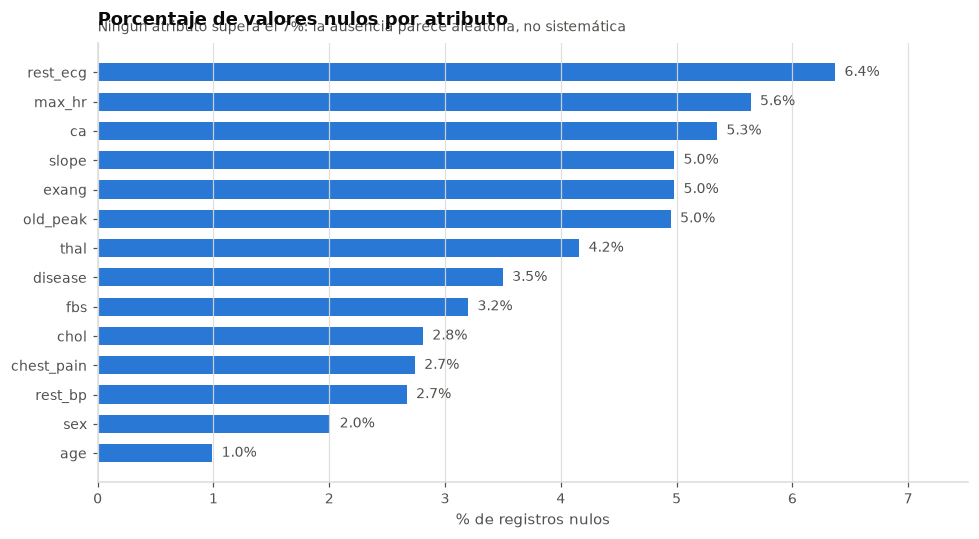

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
d = nulos.sort_values("% nulos")
b = ax.barh(d.index, d["% nulos"], color=PAL[0], height=0.62)
for rect, v in zip(b, d["% nulos"]):
    ax.text(
        v + 0.08,
        rect.get_y() + rect.get_height() / 2,
        f"{v:.1f}%",
        va="center",
        fontsize=9,
        color=TXT2,
    )
ax.set_xlim(0, d["% nulos"].max() * 1.18)
ax.set_xlabel("% de registros nulos")
ax.grid(axis="y", visible=False)
titulo(
    ax,
    "Porcentaje de valores nulos por atributo",
    "Ningún atributo supera el 7%: la ausencia parece aleatoria, no sistemática",
)
plt.tight_layout()
plt.show()

Distribución del nº de campos nulos por fila:
0     2712
1      119
2       10
5        2
6       27
7       57
8       67
9       19
10       2
14      15

Filas completamente sin nulos: 2,712 (89.5%)


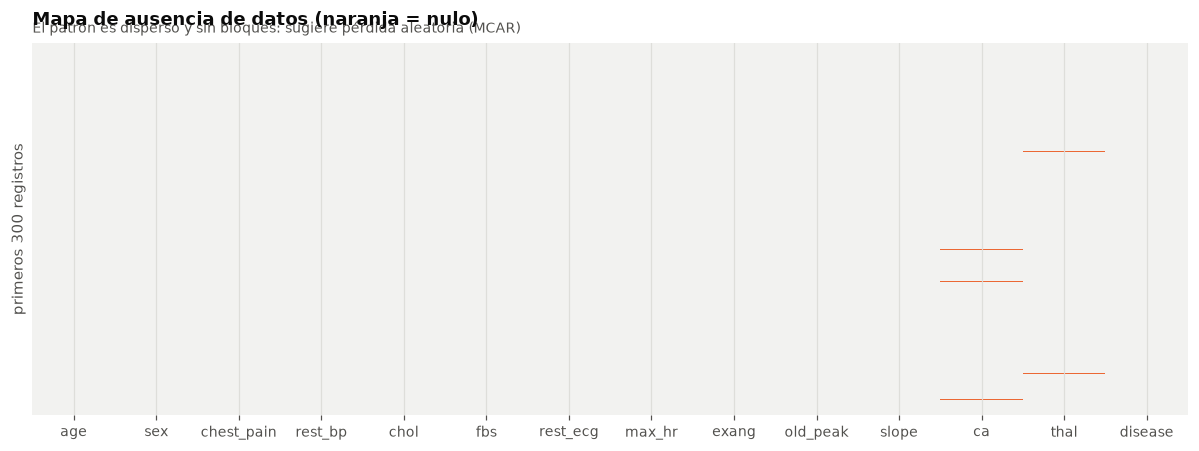

In [20]:
# ¿Los nulos se concentran en las mismas filas o están dispersos?
n_por_fila = crudo.isna().sum(axis=1)
print("Distribución del nº de campos nulos por fila:")
print(n_por_fila.value_counts().sort_index().to_string())
print(
    f"\nFilas completamente sin nulos: {(n_por_fila == 0).sum():,} "
    f"({(n_por_fila == 0).mean() * 100:.1f}%)"
)

fig, ax = plt.subplots(figsize=(11, 4.2))
sns.heatmap(crudo.isna().iloc[:300], cbar=False, cmap=["#f2f2f0", PAL[1]], ax=ax)
ax.set_yticks([])
ax.set_ylabel("primeros 300 registros")
titulo(
    ax,
    "Mapa de ausencia de datos (naranja = nulo)",
    "El patrón es disperso y sin bloques: sugiere pérdida aleatoria (MCAR)",
)
plt.tight_layout()
plt.show()

**Conclusión 3.1.** Los nulos afectan a las 14 columnas con tasas entre 1% y 6,4%.
No se agrupan en bloques ni en filas concretas, lo que apunta a un mecanismo
**MCAR (Missing Completely At Random)** — probablemente inyectado de forma artificial.
Con ~89% de filas sin ningún nulo, eliminarlas por lista (*listwise deletion*) es viable
sin sesgar la muestra; la imputación es una alternativa válida pero no imprescindible.

### 3.2 Registros duplicados

In [21]:
dups_exactos = crudo.duplicated().sum()
print(
    f"Filas exactamente duplicadas (todas las columnas): {dups_exactos:,} "
    f"({dups_exactos / len(crudo) * 100:.1f}%)"
)
print(
    f"Filas involucradas en algún grupo duplicado: {crudo.duplicated(keep=False).sum():,}"
)
print(f"Registros únicos: {len(crudo.drop_duplicates()):,}")

# ¿Cuántas veces se repite cada registro único?
rep = crudo.groupby(list(crudo.columns), dropna=False).size()
print("\nDistribución del nº de repeticiones por registro único:")
print(rep.value_counts().sort_index().to_string())

Filas exactamente duplicadas (todas las columnas): 2,462 (81.3%)
Filas involucradas en algún grupo duplicado: 2,775
Registros únicos: 568

Distribución del nº de repeticiones por registro único:
1     255
2       9
7       5
8      89
9      95
10    114
15      1


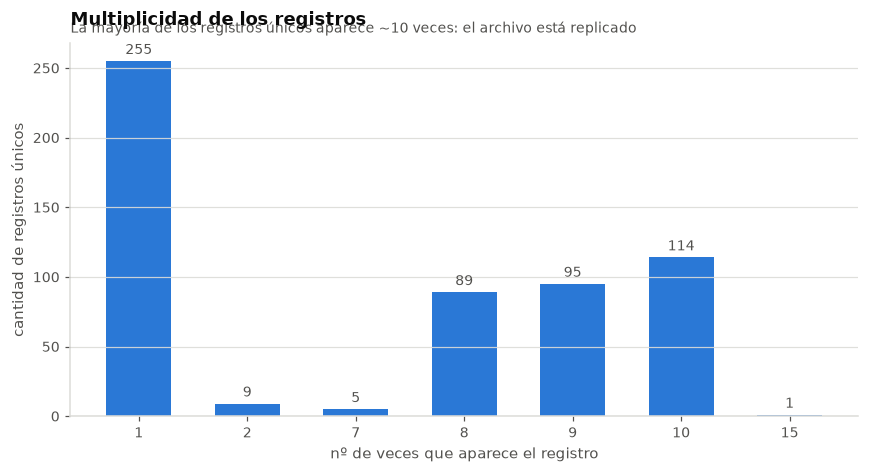

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.4))
vc = rep.value_counts().sort_index()
b = ax.bar(vc.index.astype(str), vc.values, color=PAL[0], width=0.6)
for rect, v in zip(b, vc.values):
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        v + max(vc.values) * 0.02,
        f"{v}",
        ha="center",
        fontsize=9,
        color=TXT2,
    )
ax.set_xlabel("nº de veces que aparece el registro")
ax.set_ylabel("cantidad de registros únicos")
ax.grid(axis="x", visible=False)
titulo(
    ax,
    "Multiplicidad de los registros",
    "La mayoría de los registros únicos aparece ~10 veces: el archivo está replicado",
)
plt.tight_layout()
plt.show()

> ### Hallazgo principal de la auditoría
>
> El archivo **no contiene 3.030 pacientes distintos**. Contiene aproximadamente
> **300 pacientes replicados ~10 veces**, con nulos y ruido inyectados de forma
> independiente en cada copia (por eso las copias no siempre son idénticas y el
> conteo de duplicados exactos es menor que el de filas replicadas).
>
> **Implicación metodológica — es la conclusión más importante de este notebook:**
> si no se deduplica, cualquier partición train/test tendrá **fuga de información**
> (*data leakage*): el mismo paciente aparecerá simultáneamente en entrenamiento y
> prueba, y las métricas de validación serán artificialmente optimistas.
> Además, los intervalos de confianza y los p-valores calculados sobre 3.030 filas
> serían inválidos, porque el tamaño muestral efectivo es ~10 veces menor.

### 3.3 Ruido: valores fuera de dominio

Revisamos, columna a columna, qué valores **no pertenecen al dominio esperado** definido
en el diccionario de datos.

In [23]:
NUM_ESPERADAS = [
    "age",
    "rest_bp",
    "chol",
    "max_hr",
    "old_peak",
    "fbs",
    "exang",
    "slope",
    "ca",
    "disease",
]
CAT_ESPERADAS = {
    "sex": ["Male", "Female"],
    "chest_pain": ["typical", "nontypical", "nonanginal", "asymptomatic"],
    "rest_ecg": ["normal", "left ventricular hypertrophy", "ST-T wave abnormality"],
    "thal": ["normal", "fixed", "reversable"],
}

filas = []
for c in NUM_ESPERADAS:
    conv = pd.to_numeric(crudo[c], errors="coerce")
    malos = crudo[c][conv.isna() & crudo[c].notna()]
    filas.append(
        (c, "numérica", len(malos), ", ".join(map(str, sorted(malos.unique())[:6])))
    )
for c, dom in CAT_ESPERADAS.items():
    s = crudo[c].astype("object").str.strip()
    malos = s[~s.isin(dom) & s.notna()]
    filas.append(
        (c, "categórica", len(malos), ", ".join(map(str, sorted(malos.unique())[:6])))
    )

ruido = pd.DataFrame(
    filas,
    columns=[
        "atributo",
        "tipo",
        "nº valores inválidos",
        "ejemplos de valores inválidos",
    ],
)
ruido.sort_values("nº valores inválidos", ascending=False)

,atributo,tipo,nº valores inválidos,ejemplos de valores inválidos
12,rest_ecg,categórica,5,"3563, 36653, 435647, 5653, 5678"
9,disease,numérica,5,"fsdg, fsg, g, gsfdg, sf"
13,thal,categórica,4,"365635463, 53646, 56, 87654"
11,chest_pain,categórica,3,"2345, 2435, 3456"
10,sex,categórica,3,"2345, 45, 765"
0,age,numérica,2,"fggfds, sdg"
1,rest_bp,numérica,2,"fsgh, wety"
6,exang,numérica,2,"adfs, f"
4,old_peak,numérica,2,"afd, asd"
2,chol,numérica,2,"sfdywe, wtey"


In [24]:
# Ruido "silencioso": espacios sobrantes que crean categorías fantasma
print("Categorías de rest_ecg tal como vienen (repr muestra los espacios):")
for v, n in crudo["rest_ecg"].value_counts(dropna=False).items():
    print(f"  {repr(v):48s} -> {n:5,}")

Categorías de rest_ecg tal como vienen (repr muestra los espacios):
  'normal'                                         -> 1,409
  'left ventricular hypertrophy '                  -> 1,387
  nan                                              ->   193
  'ST-T wave abnormality'                          ->    36
  '5678'                                           ->     1
  '3563'                                           ->     1
  '5653'                                           ->     1
  '36653'                                          ->     1
  '435647'                                         ->     1


**Tipología del ruido encontrado**

| Tipo de ruido | Descripción | Ejemplos | Tratamiento |
|---|---|---|---|
| **Errores tipográficos / basura** | Cadenas aleatorias en campos numéricos | `fggfds`, `wtey`, `afd` | → `NaN` (no son recuperables) |
| **Códigos fuera de dominio** | Números en campos categóricos | `2345`, `5678`, `365635463` | → `NaN` |
| **Ruido de formato (silencioso)** | Espacios sobrantes que duplican una categoría | `"left ventricular hypertrophy "` | `.str.strip()` — **recuperable** |
| **Ruido estocástico esperado** | Variabilidad natural de la medición biológica | colesterol, presión arterial | Se conserva: es señal, no error |

No se detectaron **errores de redondeo** ni inconsistencias de unidades. El ruido de
formato es el más peligroso porque no genera error al cargar: crea silenciosamente una
categoría duplicada que fragmentaría cualquier agrupación o codificación posterior.

---
## 4. Reglas de validación y limpieza

De la auditoría se derivan las reglas de validación que se aplicarán en todas las etapas
posteriores del proyecto. Se implementan en la función `limpiar()`, reutilizada
íntegramente en los Notebooks 2 y 3.

In [25]:
# =====================================================================
# Reglas de validacion y limpieza (definidas en el Notebook 1)
# =====================================================================
NUMERICAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
BINARIAS = ["fbs", "exang", "disease"]
ORDINALES = ["slope", "ca"]
NOMINALES = ["sex", "chest_pain", "rest_ecg", "thal"]

DOMINIOS = {
    "sex": ["Male", "Female"],
    "chest_pain": ["typical", "nontypical", "nonanginal", "asymptomatic"],
    "rest_ecg": ["normal", "left ventricular hypertrophy", "ST-T wave abnormality"],
    "thal": ["normal", "fixed", "reversable"],
}
RANGOS = {
    "age": (18, 100),
    "rest_bp": (80, 220),
    "chol": (100, 700),
    "max_hr": (60, 220),
    "old_peak": (0, 7),
    "slope": (1, 3),
    "ca": (0, 3),
}


def limpiar(df):
    """Aplica el casting de tipos y las reglas de dominio. Lo que no cumple -> NaN."""
    df = df.copy()
    # 1. Normalizacion de texto (espacios sobrantes, mayusculas)
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].astype("object").str.strip()
    # 2. Casting numerico: el texto basura se convierte en NaN
    for c in NUMERICAS + BINARIAS + ORDINALES:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    # 3. Dominios categoricos: los codigos invalidos se convierten en NaN
    for c, dom in DOMINIOS.items():
        df[c] = df[c].where(df[c].isin(dom))
    # 4. Dominios binarios
    for c in BINARIAS:
        df[c] = df[c].where(df[c].isin([0, 1]))
    # 5. Rangos plausibles
    for c, (lo, hi) in RANGOS.items():
        df[c] = df[c].where(df[c].between(lo, hi))
    return df


In [26]:
reglas = pd.DataFrame(
    [
        (
            "R1",
            "Todas",
            "Normalización de texto: eliminar espacios al inicio y al final",
        ),
        ("R2", "Numéricas y binarias", "Debe ser convertible a número; si no, → NaN"),
        ("R3", "sex", "∈ {Male, Female}"),
        ("R4", "chest_pain", "∈ {typical, nontypical, nonanginal, asymptomatic}"),
        (
            "R5",
            "rest_ecg",
            "∈ {normal, left ventricular hypertrophy, ST-T wave abnormality}",
        ),
        ("R6", "thal", "∈ {normal, fixed, reversable}"),
        ("R7", "fbs, exang, disease", "∈ {0, 1}"),
        ("R8", "age", "18 ≤ age ≤ 100"),
        ("R9", "rest_bp", "80 ≤ rest_bp ≤ 220 (mm Hg plausibles)"),
        ("R10", "chol", "100 ≤ chol ≤ 700 (mg/dl plausibles)"),
        ("R11", "max_hr", "60 ≤ max_hr ≤ 220 (bpm plausibles)"),
        ("R12", "old_peak", "0 ≤ old_peak ≤ 7"),
        ("R13", "slope", "∈ {1, 2, 3}"),
        ("R14", "ca", "∈ {0, 1, 2, 3}"),
        (
            "R15",
            "Registro completo",
            "Eliminar filas duplicadas exactas (evita fuga de información)",
        ),
        (
            "R16",
            "disease",
            "No puede ser nulo: sin target la fila no sirve para entrenar",
        ),
    ],
    columns=["id", "ámbito", "regla"],
)
reglas.style.hide(axis="index").set_properties(**{"text-align": "left"})

id,ámbito,regla
R1,Todas,Normalización de texto: eliminar espacios al inicio y al final
R2,Numéricas y binarias,"Debe ser convertible a número; si no, → NaN"
R3,sex,"∈ {Male, Female}"
R4,chest_pain,"∈ {typical, nontypical, nonanginal, asymptomatic}"
R5,rest_ecg,"∈ {normal, left ventricular hypertrophy, ST-T wave abnormality}"
R6,thal,"∈ {normal, fixed, reversable}"
R7,"fbs, exang, disease","∈ {0, 1}"
R8,age,18 ≤ age ≤ 100
R9,rest_bp,80 ≤ rest_bp ≤ 220 (mm Hg plausibles)
R10,chol,100 ≤ chol ≤ 700 (mg/dl plausibles)


In [27]:
df_val = limpiar(crudo)

antes = crudo.isna().sum().sum()
despues = df_val.isna().sum().sum()
print(f"Celdas nulas ANTES de validar:   {antes:,}")
print(
    f"Celdas nulas DESPUÉS de validar: {despues:,}   (+{despues - antes:,} recodificadas desde ruido)"
)

comparacion = pd.DataFrame(
    {
        "% nulos crudo": (crudo.isna().mean() * 100).round(2),
        "% nulos validado": (df_val.isna().mean() * 100).round(2),
    }
)
comparacion["Δ (ruido detectado)"] = (
    comparacion["% nulos validado"] - comparacion["% nulos crudo"]
).round(2)
comparacion

Celdas nulas ANTES de validar:   1,647
Celdas nulas DESPUÉS de validar: 1,680   (+33 recodificadas desde ruido)


,% nulos crudo,% nulos validado,Δ (ruido detectado)
age,0.990,1.060,0.070
sex,2.010,2.110,0.100
chest_pain,2.740,2.840,0.100
rest_bp,2.670,2.740,0.070
chol,2.810,2.870,0.060
fbs,3.200,3.200,0.000
rest_ecg,6.370,6.530,0.160
max_hr,5.640,5.680,0.040
exang,4.980,5.050,0.070
old_peak,4.950,5.020,0.070


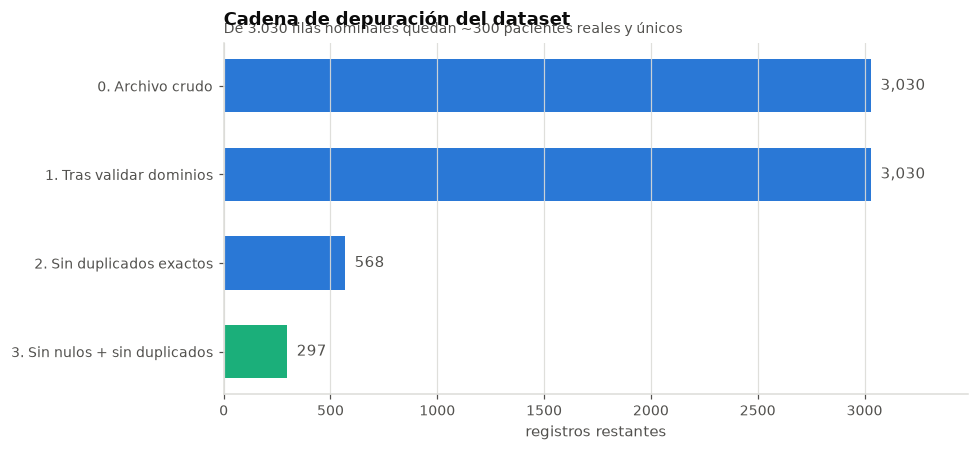


DATASET ANALÍTICO FINAL: 297 registros x 14 atributos


In [28]:
# Cadena de depuración: cuántas filas sobreviven a cada paso
paso = {}
paso["0. Archivo crudo"] = len(crudo)
paso["1. Tras validar dominios"] = len(df_val)
df_sd = df_val.drop_duplicates()
paso["2. Sin duplicados exactos"] = len(df_sd)
df_ok = df_val.dropna().drop_duplicates()
paso["3. Sin nulos + sin duplicados"] = len(df_ok)

fig, ax = plt.subplots(figsize=(9, 4.2))
ks = list(paso)[::-1]
vs = [paso[k] for k in ks]
b = ax.barh(ks, vs, color=[PAL[2]] + [PAL[0]] * 3, height=0.6)
for rect, v in zip(b, vs):
    ax.text(
        v + 45,
        rect.get_y() + rect.get_height() / 2,
        f"{v:,}",
        va="center",
        fontsize=10,
        color=TXT2,
    )
ax.set_xlim(0, max(vs) * 1.15)
ax.grid(axis="y", visible=False)
ax.set_xlabel("registros restantes")
titulo(
    ax,
    "Cadena de depuración del dataset",
    "De 3.030 filas nominales quedan ~300 pacientes reales y únicos",
)
plt.tight_layout()
plt.show()

df = df_ok.reset_index(drop=True)
df["disease"] = df["disease"].astype(int)
print(f"\nDATASET ANALÍTICO FINAL: {df.shape[0]} registros x {df.shape[1]} atributos")

> El dataset analítico queda en **297 pacientes únicos y completos** — que es
> exactamente el tamaño del conocido conjunto *Cleveland Heart Disease* del repositorio
> UCI (303 registros, 6 con valores faltantes en `ca`/`thal`). Esto confirma el
> diagnóstico: `corazon.csv` es ese dataset replicado y degradado artificialmente.
>
> **Todo el análisis a partir de aquí se hace sobre estos 297 registros.** Trabajar
> sobre las 3.030 filas daría estadísticas idénticas en promedio pero errores estándar
> ~3 veces menores de lo real, y convertiría cualquier prueba de hipótesis en un
> falso positivo garantizado.

---
## 5. Análisis univariable — variables numéricas

Para cada atributo numérico: tendencia central, medidas de dispersión, forma de la
distribución (asimetría y curtosis) y prueba de normalidad.

In [29]:
NUM = ["age", "rest_bp", "chol", "max_hr", "old_peak"]

resumen = df[NUM].describe().T
resumen["rango"] = resumen["max"] - resumen["min"]
resumen["moda"] = [df[c].mode().iloc[0] for c in NUM]
resumen["IQR"] = resumen["75%"] - resumen["25%"]
resumen["varianza"] = df[NUM].var()
resumen["CV %"] = resumen["std"] / resumen["mean"] * 100
resumen["skewness"] = df[NUM].skew()
resumen["kurtosis"] = df[NUM].kurtosis()

resumen[
    [
        "count",
        "mean",
        "50%",
        "moda",
        "min",
        "max",
        "rango",
        "std",
        "varianza",
        "IQR",
        "CV %",
        "skewness",
        "kurtosis",
    ]
].round(3)

,count,mean,50%,moda,min,max,rango,std,varianza,IQR,CV %,skewness,kurtosis
age,297.000,54.542,56.000,58.000,29.000,77.000,48.000,9.050,81.898,13.000,16.592,-0.220,-0.522
rest_bp,297.000,131.694,130.000,120.000,94.000,200.000,106.000,17.763,315.517,20.000,13.488,0.700,0.815
chol,297.000,247.350,243.000,197.000,126.000,564.000,438.000,51.998,"2,703.749",65.000,21.022,1.118,4.444
max_hr,297.000,149.599,153.000,162.000,71.000,202.000,131.000,22.942,526.315,33.000,15.335,-0.537,-0.052
old_peak,297.000,1.056,0.800,0.000,0.000,6.200,6.200,1.166,1.360,1.600,110.475,1.247,1.511


In [30]:
# Prueba de normalidad (Shapiro-Wilk) e interpretación de la forma
def forma(sk):
    if abs(sk) < 0.5:
        return "aproximadamente simétrica"
    if abs(sk) < 1.0:
        return "moderadamente asimétrica"
    return "fuertemente asimétrica"


filas = []
for c in NUM:
    s = df[c].dropna()
    W, p = stats.shapiro(s)
    sk, ku = s.skew(), s.kurtosis()
    filas.append(
        (
            c,
            round(sk, 3),
            forma(sk) + (" a la derecha" if sk > 0 else " a la izquierda"),
            round(ku, 3),
            "leptocúrtica (colas pesadas)"
            if ku > 0.5
            else "platicúrtica (colas ligeras)"
            if ku < -0.5
            else "mesocúrtica (~normal)",
            round(p, 5),
            "NO normal" if p < 0.05 else "compatible con normal",
        )
    )

pd.DataFrame(
    filas,
    columns=[
        "atributo",
        "skewness",
        "asimetría",
        "kurtosis",
        "forma de colas",
        "p-valor Shapiro",
        "conclusión (α=0.05)",
    ],
)

,atributo,skewness,asimetría,kurtosis,forma de colas,p-valor Shapiro,conclusión (α=0.05)
0,age,-0.220,aproximadamente simétrica a la izquierda,-0.522,platicúrtica (colas ligeras),0.005,NO normal
1,rest_bp,0.700,moderadamente asimétrica a la derecha,0.815,leptocúrtica (colas pesadas),0.000,NO normal
2,chol,1.118,fuertemente asimétrica a la derecha,4.444,leptocúrtica (colas pesadas),0.000,NO normal
3,max_hr,-0.537,moderadamente asimétrica a la izquierda,-0.052,mesocúrtica (~normal),0.000,NO normal
4,old_peak,1.247,fuertemente asimétrica a la derecha,1.511,leptocúrtica (colas pesadas),0.000,NO normal


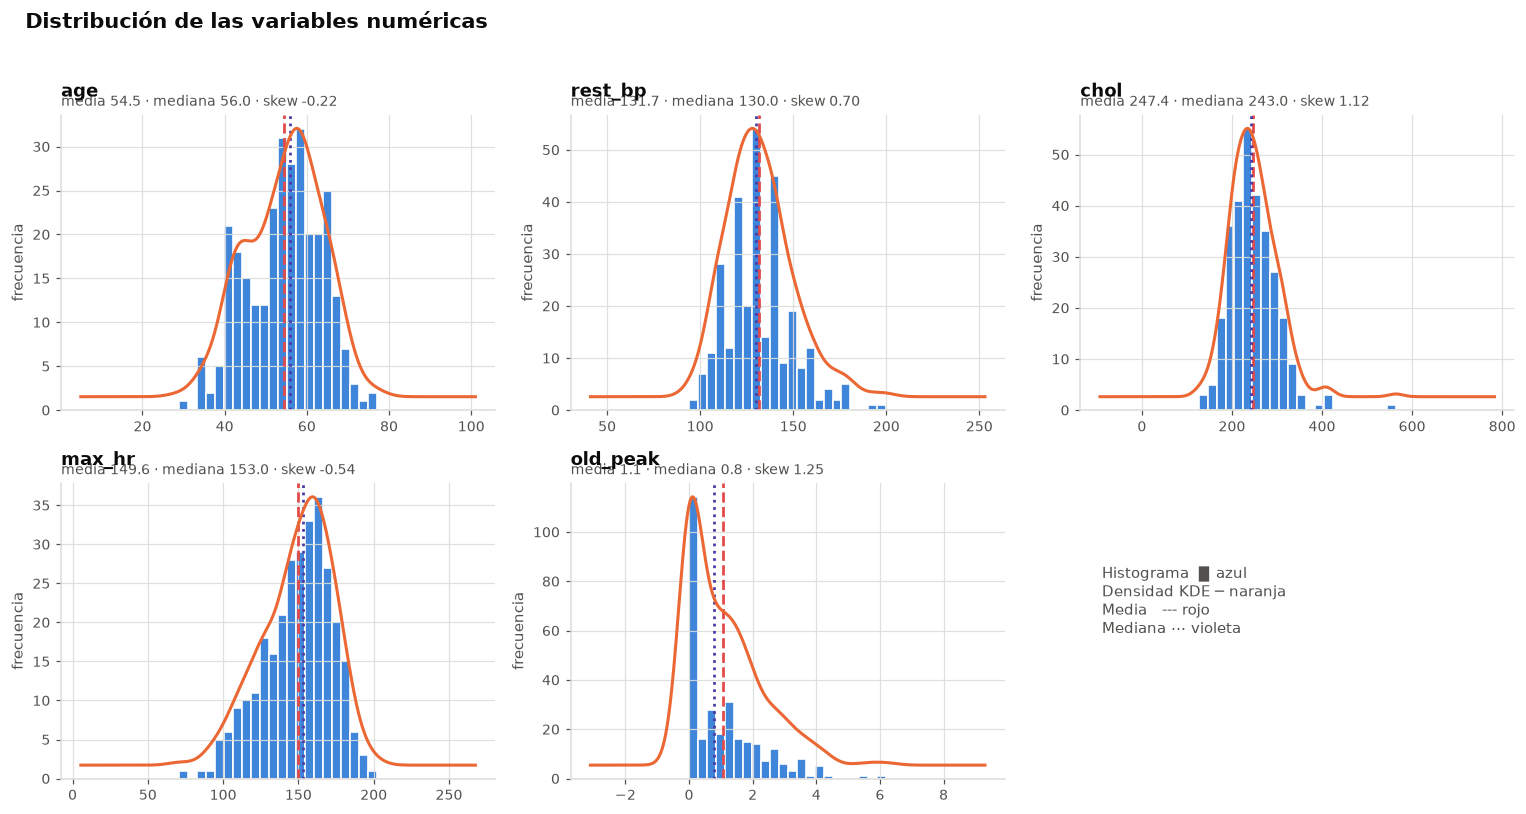

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, c in zip(axes.ravel(), NUM):
    s = df[c].dropna()
    ax.hist(s, bins=22, color=PAL[0], edgecolor="white", linewidth=1.2, alpha=0.9)
    ax2 = ax.twinx()
    s.plot(kind="kde", ax=ax2, color=PAL[1], lw=2)
    ax2.set_yticks([])
    ax2.set_ylabel("")
    ax2.grid(False)
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax.axvline(s.mean(), color=PAL[7], ls="--", lw=1.8)
    ax.axvline(s.median(), color=PAL[6], ls=":", lw=1.8)
    titulo(
        ax, c, f"media {s.mean():.1f} · mediana {s.median():.1f} · skew {s.skew():.2f}"
    )
    ax.set_ylabel("frecuencia")
axes.ravel()[-1].axis("off")
axes.ravel()[-1].text(
    0.05,
    0.6,
    "Histograma  ▉ azul\nDensidad KDE ─ naranja\nMedia   --- rojo\nMediana ⋯ violeta",
    fontsize=10,
    color=TXT2,
    va="center",
)
plt.suptitle(
    "Distribución de las variables numéricas",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

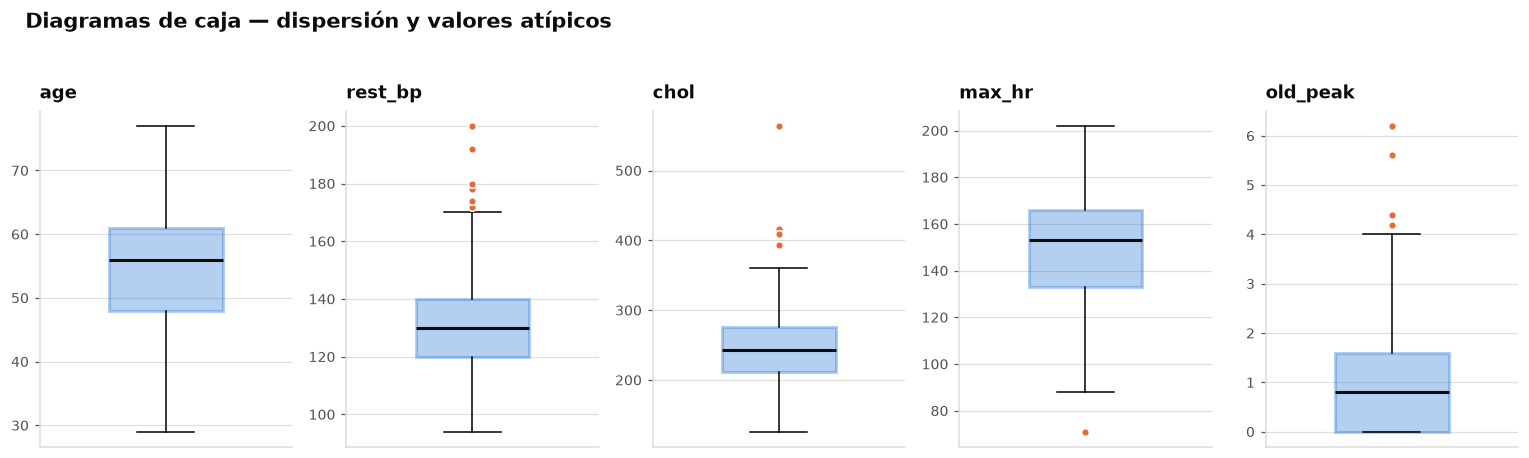

In [32]:
fig, axes = plt.subplots(1, 5, figsize=(14, 4.2))
for ax, c in zip(axes, NUM):
    bp = ax.boxplot(
        df[c].dropna(),
        widths=0.45,
        patch_artist=True,
        medianprops=dict(color=TXT, lw=2),
        flierprops=dict(
            marker="o", markersize=5, markerfacecolor=PAL[1], markeredgecolor="white"
        ),
    )
    bp["boxes"][0].set(facecolor=PAL[0], alpha=0.35, edgecolor=PAL[0], linewidth=2)
    ax.set_xticks([])
    titulo(ax, c)
    ax.grid(axis="x", visible=False)
plt.suptitle(
    "Diagramas de caja — dispersión y valores atípicos",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

**Lectura de las distribuciones**

- **`age`** — casi simétrica y ligeramente platicúrtica; población concentrada entre 48 y 61 años.
  Es la variable mejor comportada del conjunto.
- **`rest_bp`** — asimetría positiva moderada, con acumulación en valores redondos
  (120, 130, 140 mm Hg): artefacto habitual del registro clínico manual.
- **`chol`** — la más asimétrica a la derecha y la única claramente leptocúrtica; unos pocos
  pacientes con colesterol extremo (>400 mg/dl) estiran la cola. Candidata natural a
  transformación logarítmica.
- **`max_hr`** — asimétrica a la izquierda: hay un techo fisiológico (~220 − edad) que
  trunca la distribución por arriba.
- **`old_peak`** — fuertemente asimétrica a la derecha y con una masa importante en el
  valor 0 (pacientes sin depresión del ST). No es continua pura sino
  **semicontinua con inflación en cero**, lo que hace poco útil una transformación log simple.

Ninguna variable pasa la prueba de Shapiro-Wilk. Esto **no invalida el análisis**, pero sí
recomienda usar pruebas no paramétricas (Mann-Whitney, Spearman) en el Notebook 2 y
escalado robusto en lugar de estandarización clásica.

---
## 6. Análisis univariable — variables categóricas

In [33]:
CAT = ["sex", "chest_pain", "rest_ecg", "thal", "fbs", "exang", "slope", "ca"]

for c in CAT:
    vc = df[c].value_counts(dropna=False)
    tab = pd.DataFrame({"frecuencia": vc, "%": (vc / len(df) * 100).round(1)})
    print(f"\n=== {c} ===  (categorías distintas: {df[c].nunique()})")
    print(tab.to_string())


=== sex ===  (categorías distintas: 2)
        frecuencia      %
sex                      
Male           201 67.700
Female          96 32.300

=== chest_pain ===  (categorías distintas: 4)
              frecuencia      %
chest_pain                     
asymptomatic         142 47.800
nonanginal            83 27.900
nontypical            49 16.500
typical               23  7.700

=== rest_ecg ===  (categorías distintas: 3)
                              frecuencia      %
rest_ecg                                       
normal                               147 49.500
left ventricular hypertrophy         146 49.200
ST-T wave abnormality                  4  1.300

=== thal ===  (categorías distintas: 3)
            frecuencia      %
thal                         
normal             164 55.200
reversable         115 38.700
fixed               18  6.100

=== fbs ===  (categorías distintas: 2)
       frecuencia      %
fbs                     
0.000         254 85.500
1.000          43 14.500



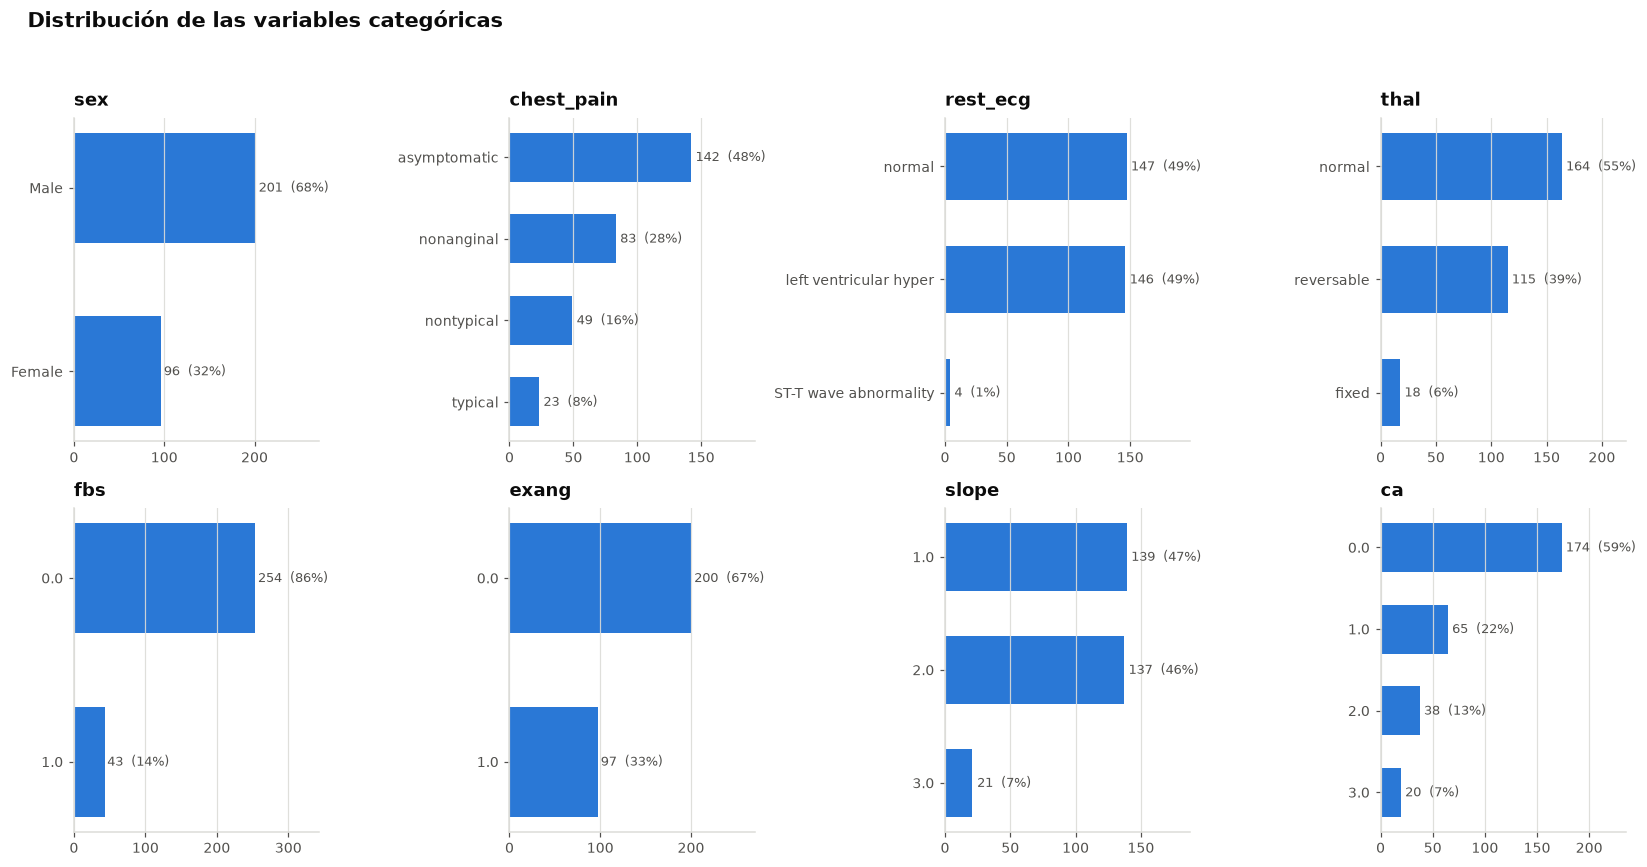

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, c in zip(axes.ravel(), CAT):
    vc = df[c].value_counts().sort_values()
    etiquetas = [str(i)[:22] for i in vc.index]
    b = ax.barh(etiquetas, vc.values, color=PAL[0], height=0.6)
    for rect, v in zip(b, vc.values):
        ax.text(
            v + len(df) * 0.012,
            rect.get_y() + rect.get_height() / 2,
            f"{v}  ({v / len(df) * 100:.0f}%)",
            va="center",
            fontsize=8.5,
            color=TXT2,
        )
    ax.set_xlim(0, vc.max() * 1.35)
    ax.grid(axis="y", visible=False)
    titulo(ax, c)
plt.suptitle(
    "Distribución de las variables categóricas",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [35]:
# Desbalance interno de cada categórica: ¿hay categorías muy minoritarias?
filas = []
for c in CAT:
    p = df[c].value_counts(normalize=True)
    entropia = -(p * np.log2(p)).sum()
    filas.append(
        (
            c,
            len(p),
            round(p.max() * 100, 1),
            str(p.idxmax())[:26],
            round(p.min() * 100, 1),
            str(p.idxmin())[:26],
            round(entropia, 3),
            "SÍ — categoría < 5%" if p.min() < 0.05 else "no",
        )
    )
pd.DataFrame(
    filas,
    columns=[
        "atributo",
        "nº categorías",
        "% mayoritaria",
        "categoría mayoritaria",
        "% minoritaria",
        "categoría minoritaria",
        "entropía (bits)",
        "¿desbalance severo?",
    ],
)

,atributo,nº categorías,% mayoritaria,categoría mayoritaria,% minoritaria,categoría minoritaria,entropía (bits),¿desbalance severo?
0,sex,2,67.700,Male,32.300,Female,0.908,no
1,chest_pain,4,47.800,asymptomatic,7.700,typical,1.738,no
2,rest_ecg,3,49.500,normal,1.300,ST-T wave abnormality,1.090,SÍ — categoría < 5%
3,thal,3,55.200,normal,6.100,fixed,1.248,no
4,fbs,2,85.500,0.0,14.500,1.0,0.597,no
5,exang,2,67.300,0.0,32.700,1.0,0.911,no
6,slope,3,46.800,1.0,7.100,3.0,1.298,no
7,ca,4,58.600,0.0,6.700,3.0,1.573,no


**Lectura de las categóricas**

- **`sex`** — ~68% hombres. El desbalance es real y conocido en esta cohorte, no un error;
  obliga a analizar los resultados por sexo (Notebook 2) para no generalizar de más.
- **`chest_pain`** — la categoría dominante es `asymptomatic` (~48%), lo cual es
  contraintuitivo hasta recordar que se trata de pacientes ya derivados a angiografía.
- **`rest_ecg`** — `ST-T wave abnormality` aparece en **~1% de los casos** (4 pacientes).
  Es un problema práctico: una categoría con 4 observaciones no permite estimar nada de
  forma fiable y generará celdas vacías en las tablas de contingencia. **Recomendación:
  fusionarla con `left ventricular hypertrophy` en una categoría "ECG anormal".**
- **`ca`** y **`old_peak`** están fuertemente concentradas en 0, lo que las hace
  informativas justo en la cola (los valores altos son los que discriminan).
- **`fbs`** — solo ~15% positivos y, como se verá en el Notebook 2, prácticamente sin
  relación con el target: es la principal candidata a ser descartada.

---
## 7. Detección de valores atípicos

Se comparan dos criterios: el **rango intercuartílico (Tukey)**, robusto y adecuado para
distribuciones asimétricas, y la **puntuación z**, que asume normalidad. Se marca cada
atípico como *plausible* (clínicamente posible) o *imposible* (violaría las reglas de validación).

In [36]:
filas = []
for c in NUM:
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_iqr = s[(s < lo) | (s > hi)]
    z = np.abs(stats.zscore(s))
    out_z = s[z > 3]
    filas.append(
        (
            c,
            round(lo, 2),
            round(hi, 2),
            len(out_iqr),
            round(len(out_iqr) / len(s) * 100, 1),
            len(out_z),
            round(s.max(), 1),
            "todos plausibles clínicamente",
        )
    )
pd.DataFrame(
    filas,
    columns=[
        "atributo",
        "límite inf. (Tukey)",
        "límite sup. (Tukey)",
        "atípicos IQR",
        "% atípicos",
        "atípicos |z|>3",
        "máximo observado",
        "valoración",
    ],
)

,atributo,límite inf. (Tukey),límite sup. (Tukey),atípicos IQR,% atípicos,atípicos |z|>3,máximo observado,valoración
0,age,28.500,80.500,0,0.000,0,77.000,todos plausibles clínicamente
1,rest_bp,90.000,170.000,9,3.000,2,200.000,todos plausibles clínicamente
2,chol,113.500,373.500,5,1.700,4,564.000,todos plausibles clínicamente
3,max_hr,83.500,215.500,1,0.300,1,202.000,todos plausibles clínicamente
4,old_peak,-2.400,4.000,5,1.700,2,6.200,todos plausibles clínicamente


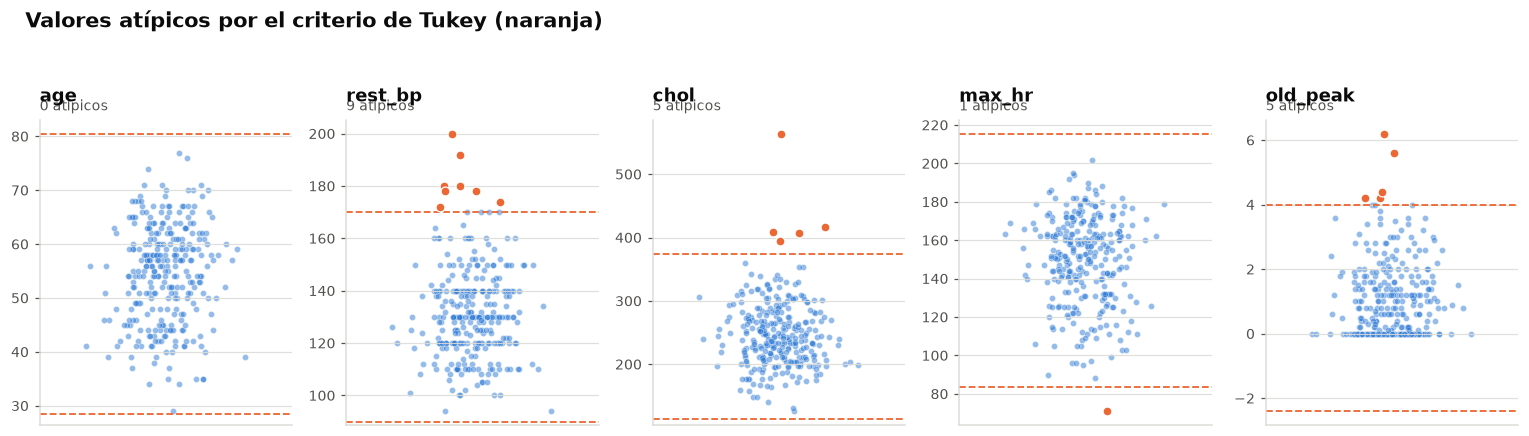

In [37]:
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for ax, c in zip(axes, NUM):
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    es_out = (s < lo) | (s > hi)
    x = np.random.default_rng(0).normal(0, 0.045, len(s))
    ax.scatter(
        x[~es_out.values],
        s[~es_out],
        s=16,
        color=PAL[0],
        alpha=0.5,
        edgecolor="white",
        linewidth=0.4,
    )
    ax.scatter(
        x[es_out.values],
        s[es_out],
        s=34,
        color=PAL[1],
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )
    ax.axhline(hi, color=PAL[1], ls="--", lw=1.2)
    ax.axhline(lo, color=PAL[1], ls="--", lw=1.2)
    ax.set_xticks([])
    ax.set_xlim(-0.22, 0.22)
    titulo(ax, c, f"{int(es_out.sum())} atípicos")
    ax.grid(axis="x", visible=False)
plt.suptitle(
    "Valores atípicos por el criterio de Tukey (naranja)",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Decisión sobre los atípicos.** Tras aplicar las reglas de validación, todos los
valores extremos que quedan son **clínicamente plausibles**: un colesterol de 564 mg/dl o
una presión de 200 mm Hg son cifras raras pero reales, y precisamente en pacientes
cardiológicos. Además, son casos graves — justo los que un modelo de diagnóstico debe
acertar. **No se eliminan.** La mitigación adecuada es metodológica: escalado robusto
(`RobustScaler`), transformaciones que compriman la cola, o algoritmos basados en árboles,
que son insensibles a los extremos.

---
## 8. La variable objetivo: `disease`

In [38]:
vc = df["disease"].value_counts().sort_index()
prop = df["disease"].value_counts(normalize=True).sort_index()
print(f"Clase 0 (sin enfermedad): {vc[0]:>4}  ({prop[0] * 100:.1f}%)")
print(f"Clase 1 (con enfermedad): {vc[1]:>4}  ({prop[1] * 100:.1f}%)")
print(f"\nRatio de desbalance: {vc.max() / vc.min():.2f} : 1")
print(
    f"Precisión del clasificador trivial (predecir siempre la clase mayoritaria): {prop.max() * 100:.1f}%"
)
print(
    "\n-> Desbalance leve. No se requiere sobremuestreo (SMOTE) ni ponderación de clases."
)
print("-> La exactitud (accuracy) es una métrica aceptable, pero se reportarán también")
print(
    "   sensibilidad y AUC: en diagnóstico médico un falso negativo es mucho más costoso."
)

Clase 0 (sin enfermedad):  160  (53.9%)
Clase 1 (con enfermedad):  137  (46.1%)

Ratio de desbalance: 1.17 : 1
Precisión del clasificador trivial (predecir siempre la clase mayoritaria): 53.9%

-> Desbalance leve. No se requiere sobremuestreo (SMOTE) ni ponderación de clases.
-> La exactitud (accuracy) es una métrica aceptable, pero se reportarán también
   sensibilidad y AUC: en diagnóstico médico un falso negativo es mucho más costoso.


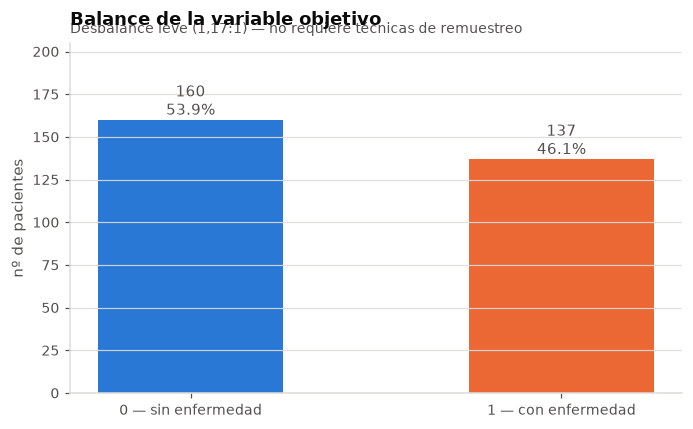

In [39]:
fig, ax = plt.subplots(figsize=(6.4, 4))
b = ax.bar(
    ["0 — sin enfermedad", "1 — con enfermedad"],
    vc.values,
    color=[PAL[0], PAL[1]],
    width=0.5,
)
for rect, v in zip(b, vc.values):
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        v + 3,
        f"{v}\n{v / len(df) * 100:.1f}%",
        ha="center",
        fontsize=10,
        color=TXT2,
    )
ax.set_ylim(0, vc.max() * 1.28)
ax.set_ylabel("nº de pacientes")
ax.grid(axis="x", visible=False)
titulo(
    ax,
    "Balance de la variable objetivo",
    "Desbalance leve (1,17:1) — no requiere técnicas de remuestreo",
)
plt.tight_layout()
plt.show()

---
## 9. Preparación de datos e ingeniería de atributos

Recomendaciones derivadas del análisis univariable, para la etapa de modelado.

### 9.1 Transformaciones necesarias

| Atributo | Problema detectado | Transformación recomendada |
|---|---|---|
| `chol` | Asimetría positiva fuerte, colas pesadas | `log1p` o Yeo-Johnson |
| `old_peak` | Semicontinua con exceso de ceros | Discretizar en {0, bajo, alto} **o** añadir un indicador binario `old_peak = 0` |
| `rest_bp` | Asimetría moderada, redondeo a valores múltiplos de 10 | `RobustScaler`; opcionalmente categorizar según guías clínicas de hipertensión |
| `age`, `max_hr` | Bien comportadas | Escalado estándar |
| `sex`, `chest_pain`, `thal` | Nominales | One-hot encoding (`drop_first` para evitar colinealidad) |
| `slope`, `ca` | **Ordinales** | Label encoding respetando el orden (no one-hot: se perdería el orden) |
| `rest_ecg` | Categoría con 4 casos | Fusionar en binaria: normal / anormal |
| `fbs` | Muy desbalanceada y poco informativa | Candidata a eliminación (se confirma en el Notebook 2) |

### 9.2 Atributos derivados propuestos

- **`reserva_fc` = 220 − `age` − `max_hr`** — cuánto le falta al paciente para alcanzar su
  frecuencia cardíaca máxima teórica. Normaliza `max_hr` por edad y es más interpretable
  clínicamente que la frecuencia bruta.
- **`grupo_edad`** — franjas (<45, 45-54, 55-64, ≥65) para capturar efectos no lineales
  de la edad y facilitar la lectura de reglas heurísticas.
- **`isquemia`** = `exang` + (`old_peak` > 1) + (`slope` = 3) — índice acumulado de
  signos de isquemia inducida por esfuerzo, agrupando tres señales que miden lo mismo.
- **`chol_alto`** = `chol` ≥ 240 — umbral clínico estándar; convierte una variable
  ruidosa en una señal binaria interpretable.

### 9.3 Datos adicionales que serían útiles

- **Identificador de paciente y fecha del estudio** — habrían permitido detectar la
  replicación sin tener que inferirla, y son imprescindibles para una partición correcta.
- **Tabaquismo, diabetes, IMC, antecedentes familiares** — factores de riesgo
  cardiovascular de primer orden, ausentes aquí.
- **Medicación en curso** (betabloqueantes) — altera directamente `max_hr` y `rest_bp`,
  y es una variable de confusión potencial no observada.
- **Colesterol desglosado en HDL/LDL** — el colesterol total es notoriamente poco
  discriminante comparado con sus fracciones; explicaría la débil señal de `chol`.
- **Severidad del diagnóstico** — el dataset original codifica `disease` en 5 niveles
  (0-4); aquí está binarizado, lo que descarta la opción de un modelo ordinal.

---
## 10. Conclusiones del análisis univariable

In [40]:
df.to_csv("corazon_limpio.csv", index=False)
print(
    f"Dataset validado exportado a 'corazon_limpio.csv' -> {df.shape[0]} filas x {df.shape[1]} columnas"
)
print("Los Notebooks 2 y 3 parten de este archivo.\n")
df.describe(include="all").T

Dataset validado exportado a 'corazon_limpio.csv' -> 297 filas x 14 columnas
Los Notebooks 2 y 3 parten de este archivo.



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,297.000,NaN,NaN,NaN,54.542,9.050,29.000,48.000,56.000,61.000,77.000
sex,297,2,Male,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chest_pain,297,4,asymptomatic,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rest_bp,297.000,NaN,NaN,NaN,131.694,17.763,94.000,120.000,130.000,140.000,200.000
chol,297.000,NaN,NaN,NaN,247.350,51.998,126.000,211.000,243.000,276.000,564.000
fbs,297.000,NaN,NaN,NaN,0.145,0.352,0.000,0.000,0.000,0.000,1.000
rest_ecg,297,3,normal,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_hr,297.000,NaN,NaN,NaN,149.599,22.942,71.000,133.000,153.000,166.000,202.000
exang,297.000,NaN,NaN,NaN,0.327,0.470,0.000,0.000,0.000,1.000,1.000
old_peak,297.000,NaN,NaN,NaN,1.056,1.166,0.000,0.000,0.800,1.600,6.200


### Síntesis

1. **El archivo no es lo que aparenta.** Sus 3.030 filas se reducen a **297 pacientes
   únicos y válidos**: el dataset base está replicado ~10 veces con nulos y ruido
   inyectados. Ignorar esto produciría métricas de modelado infladas por fuga de
   información y pruebas estadísticas inválidas. Este es el hallazgo central del análisis.

2. **La calidad de los datos está deliberadamente degradada** en tres capas: valores
   nulos MCAR (1–6% por columna), cadenas de texto basura en campos numéricos, códigos
   fuera de dominio en campos categóricos, y ruido de formato (espacios sobrantes) que no
   provoca error al cargar pero fragmenta las categorías. Se han codificado **16 reglas de
   validación** que capturan todos estos casos.

3. **Ninguna variable numérica es normal.** `chol` y `old_peak` presentan asimetría
   positiva fuerte; `max_hr` está truncada por el techo fisiológico. Esto orienta el
   Notebook 2 hacia pruebas no paramétricas y sugiere escalado robusto para el modelado.

4. **Los valores atípicos son reales y se conservan.** Todos los extremos que sobreviven a
   la validación son clínicamente plausibles y corresponden a los casos más graves,
   justamente los que interesa clasificar bien.

5. **El target está bien balanceado** (54% / 46%). No hacen falta técnicas de remuestreo,
   y el listón a superar por cualquier modelo es el **54% del clasificador trivial**.

6. **Dos atributos requieren atención estructural antes de modelar:** `rest_ecg`
   (categoría con solo 4 casos → fusionar) y `fbs` (muy desbalanceada y a priori poco
   informativa → verificar en el Notebook 2 antes de descartar).

**Siguiente paso →** el *Notebook 2 — Análisis Bivariable* cuantifica la relación de cada
atributo con `disease` y entre pares de atributos, para establecer un ranking de poder
predictivo.